# Age Estimation 

In [1]:
import numpy as np
import os
from helperP import *

# Loading Data

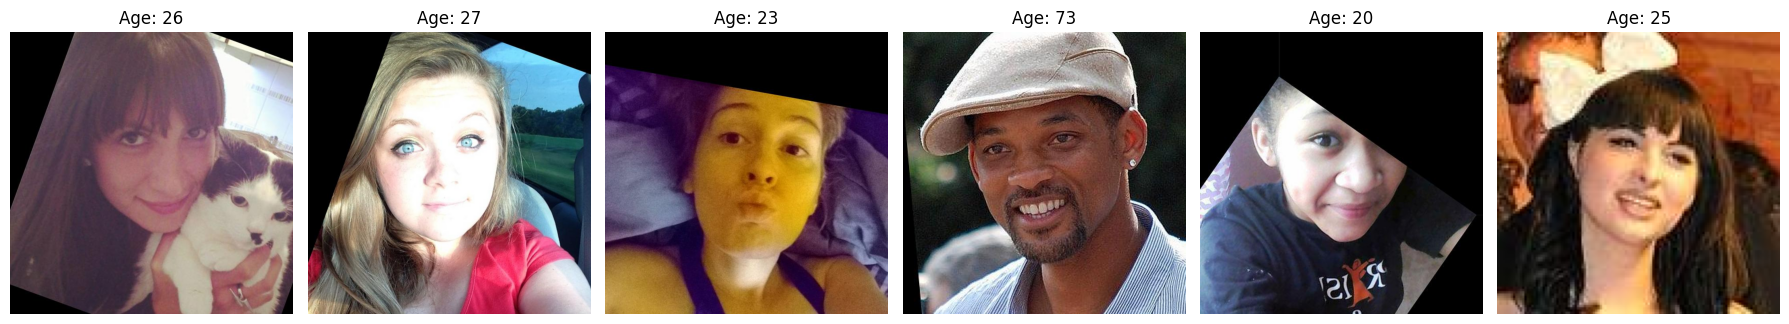

In [2]:
base_dir = 'DATASET/'

age_train, features_train = prepare_data('train', base_dir)
age_val, features_val = prepare_data('val', base_dir)
_, features_test = prepare_data('test', base_dir)
show_data(base_dir)

# Implement Closed Form Solution
```
Arguments:
    age          -- numpy array, shape (n, )
    features     -- numpy array, shape (n, 2048)
Returns:
    weights      -- numpy array, (2048, )
    bias         -- numpy array, (1, )
```

In [3]:
def closed_form_solution(age, features):
    # Preprocess
    H = features
    ones = np.ones(len(H))
    H = np.column_stack((ones, H))
    Y = age
    
    # Solve least squares: min ||Hw - Y||^2
    # Closed form: w* = (H^T H)^{-1} H^T Y, solved via lstsq for numerical stability
    weights = np.linalg.lstsq(H, Y, rcond=None)[0]

    # separate the weights and bias
    bias    = weights[0]
    weights = weights[1:]
    
    return weights, bias


# Validate

In [4]:
w, b = closed_form_solution(age_train, features_train)
loss, pred = evaluate(w, b, age_val, features_val)
print("Your validate loss is:", round(loss, 3))

Your validate loss is: 5.925


# Test and Generate results file

In [5]:
prediction = test(w, b, features_test, 'cfs.txt')
print("Test results has saved to cfs.txt")
print(prediction[:10])


Test results has saved to cfs.txt
[28.04639958 60.90374507 55.19594956 23.35683532 35.20122174 34.36335502
 36.63257241 44.11504394 18.49147778 57.60077164]


# Implement Gradient descent
Gradient descent is an optimization algorithm used to minimize some function by iteratively moving in the direction of steepest descent as defined by the negative of the gradient. In machine learning, we use gradient descent to update the parameters of our model.

```
Arguments:
    age          -- numpy array, label, (n, )
    feature      -- numpy array, features, (n, 2048)
Return:
    weights      -- numpy array, (2048, )
    bias         -- numpy array, (1, )
```

In [6]:
def gradient_descent(age, feature):
    assert len(age) == len(feature)

    # Init weights and bias
    np.random.seed(0)
    weights = np.random.randn(2048, 1)
    bias = np.random.randn(1, 1)
    
    # Learning rate
    lr = 10e-3
    
    n = len(age)
    best_weights, best_bias = weights.copy(), bias.copy()
    best_val_loss = float('inf')

    for e in range(epoch):
        # forward pass
        pred = feature @ weights + bias          # (n, 1)

        # calculate loss
        diff = pred - age.reshape(-1, 1)         # (n, 1)
        loss = float(np.mean(diff ** 2))

        # calculate gradient
        grad_w = feature.T @ diff / n            # (2048, 1)
        grad_b = float(diff.mean())

        # update weights
        weights = weights - lr * grad_w
        bias    = bias    - lr * grad_b

        if momentum:
            pass  # You can also consider the gradient descent with momentum

    return weights, bias


# Train and validate

In [7]:
w, b = gradient_descent(age_train, features_train)
loss, pred = evaluate(w, b, age_val, features_val)
print("Your validate score is:", round(loss, 3))

Your validate score is: 6.376


#  Test and Generate results file

In [8]:
prediction = test(w, b, features_test, 'gd.txt')
print("Test results has saved to gd.txt")
print(prediction[:10])

Test results has saved to gd.txt
[23.10269928 74.73559946 54.55902549 23.83843303 31.87846008 27.89465342
 25.23894825 39.209773   23.80830329 52.51746872]


# Implement Stochastic Gradient descent
Stochastic Gradient Descent (SGD) is a simple yet very efficient approach to discriminative learning of linear classifiers under convex loss functions such as (linear) Support Vector Machines and Logistic Regression. Even though SGD has been around in the machine learning community for a long time, it has received a considerable amount of attention just recently in the context of large-scale learning.
```
Arguments:
    age          -- numpy array, label, (n, )
    feature      -- numpy array, features, (n, 2048)
Return:
    weights      -- numpy array, (2048, )
    bias         -- numpy array, (1, )
```

In [9]:
def stochastic_gradient_descent(age, feature):
    # check the inputs
    assert len(age) == len(feature)
    
    # Set the random seed
    np.random.seed(0)

    # Init weights and bias
    weights = np.random.rand(2048, 1)
    bias = np.random.rand(1, 1)

    # Learning rate
    lr = 10e-5

    # Batch size
    batch_size = 16
 
    # Number of mini-batches
    t = len(age) // batch_size

    loss = 0.0
    for e in range(epoch_sgd):
        # Shuffle training data
        n = np.random.permutation(len(feature))  
        
        for m in range(t):
            # Providing mini batch with fixed batch size of 16
            batch_feature = feature[n[m * batch_size : (m+1) * batch_size]]
            batch_age = age[n[m * batch_size : (m+1) * batch_size]]
            
            # forward pass
            pred = batch_feature @ weights + bias        # (B, 1)

            # calculate loss
            diff = pred - batch_age.reshape(-1, 1)       # (B, 1)
            loss = float(np.mean(diff ** 2))

            # calculate gradient
            B = len(batch_age)
            grad_w = batch_feature.T @ diff / B          # (2048, 1)
            grad_b = float(diff.mean())

            # update weights
            weights = weights - lr * grad_w
            bias    = bias    - lr * grad_b
   
            if momentum:
                pass  # You can also consider the gradient descent with momentum
        
        print('=> epoch:', e + 1, '  Loss:', round(loss, 4))
    return weights, bias


# Train and validate

In [10]:
w, b = stochastic_gradient_descent(age_train, features_train)
loss, pred = evaluate(w, b, age_val, features_val)
print("Your validate score is:", round(loss, 3))

=> epoch: 1   Loss: 557.3732
=> epoch: 2   Loss: 94.8359
=> epoch: 3   Loss: 64.1817
=> epoch: 4   Loss: 108.148
=> epoch: 5   Loss: 26.1287
=> epoch: 6   Loss: 57.4358
=> epoch: 7   Loss: 17.7613
=> epoch: 8   Loss: 36.7035
=> epoch: 9   Loss: 45.0413
=> epoch: 10   Loss: 26.5215
=> epoch: 11   Loss: 31.7509
=> epoch: 12   Loss: 25.9076
=> epoch: 13   Loss: 24.8545
=> epoch: 14   Loss: 18.4206
=> epoch: 15   Loss: 16.1177
=> epoch: 16   Loss: 71.9767
=> epoch: 17   Loss: 44.763
=> epoch: 18   Loss: 16.2385
=> epoch: 19   Loss: 32.5552
=> epoch: 20   Loss: 34.93


=> epoch: 21   Loss: 29.331
=> epoch: 22   Loss: 22.6736
=> epoch: 23   Loss: 78.6225


=> epoch: 24   Loss: 41.1978
=> epoch: 25   Loss: 21.8831
=> epoch: 26   Loss: 9.7615
=> epoch: 27   Loss: 45.0868
=> epoch: 28   Loss: 42.4315
=> epoch: 29   Loss: 33.5472
=> epoch: 30   Loss: 11.0968
=> epoch: 31   Loss: 70.2809
=> epoch: 32   Loss: 27.9529
=> epoch: 33   Loss: 12.5265
=> epoch: 34   Loss: 77.3817
=> epoch: 35   Loss: 41.6765
=> epoch: 36   Loss: 36.6161
=> epoch: 37   Loss: 25.3457
=> epoch: 38   Loss: 64.0658
=> epoch: 39   Loss: 48.6955
=> epoch: 40   Loss: 41.4274
=> epoch: 41   Loss: 31.4834
=> epoch: 42   Loss: 23.3825
=> epoch: 43   Loss: 19.1709
=> epoch: 44   Loss: 9.4619
=> epoch: 45   Loss: 18.2846
=> epoch: 46   Loss: 52.028


=> epoch: 47   Loss: 58.1703
=> epoch: 48   Loss: 34.0233
=> epoch: 49   Loss: 59.6511


=> epoch: 50   Loss: 33.3803
=> epoch: 51   Loss: 27.1609
=> epoch: 52   Loss: 20.5461
=> epoch: 53   Loss: 29.4025
=> epoch: 54   Loss: 37.9964
=> epoch: 55   Loss: 75.8677
=> epoch: 56   Loss: 22.2932
=> epoch: 57   Loss: 22.6025
=> epoch: 58   Loss: 100.4483
=> epoch: 59   Loss: 14.8426
=> epoch: 60   Loss: 20.8359
=> epoch: 61   Loss: 42.4781
=> epoch: 62   Loss: 15.1427
=> epoch: 63   Loss: 23.5456
=> epoch: 64   Loss: 13.5857
=> epoch: 65   Loss: 40.9963
=> epoch: 66   Loss: 16.2753
=> epoch: 67   Loss: 59.2789
=> epoch: 68   Loss: 30.6295
=> epoch: 69   Loss: 42.2902
=> epoch: 70   Loss: 47.7619
=> epoch: 71   Loss: 71.2642


=> epoch: 72   Loss: 11.2606
=> epoch: 73   Loss: 23.5416
=> epoch: 74   Loss: 11.4344


=> epoch: 75   Loss: 66.8095
=> epoch: 76   Loss: 21.6048
=> epoch: 77   Loss: 31.4743
=> epoch: 78   Loss: 18.3949
=> epoch: 79   Loss: 20.3772
=> epoch: 80   Loss: 42.0903
=> epoch: 81   Loss: 45.1512
=> epoch: 82   Loss: 25.5845
=> epoch: 83   Loss: 30.816
=> epoch: 84   Loss: 20.7959
=> epoch: 85   Loss: 14.1556
=> epoch: 86   Loss: 27.8968
=> epoch: 87   Loss: 22.8561
=> epoch: 88   Loss: 42.1739
=> epoch: 89   Loss: 30.8641
=> epoch: 90   Loss: 64.2479
=> epoch: 91   Loss: 42.7053
=> epoch: 92   Loss: 22.1798
=> epoch: 93   Loss: 27.8701
=> epoch: 94   Loss: 45.4189
=> epoch: 95   Loss: 19.9914
=> epoch: 96   Loss: 24.9081


=> epoch: 97   Loss: 45.7964
=> epoch: 98   Loss: 16.7693
=> epoch: 99   Loss: 30.1682


=> epoch: 100   Loss: 60.4171
Your validate score is: 5.751


# Test and Generate results file

In [11]:
prediction = test(w, b, features_test, 'sgd.txt')
print("Test results has saved to sgd.txt")
print(prediction[:10])

Test results has saved to sgd.txt
[26.4712843  76.22092118 54.08500022 22.41484943 33.50991962 28.94436494
 28.32268237 40.28594426 22.82754715 52.9453773 ]
